In [1]:
import pandas as pd
import os
import numpy as np
import pickle

In [2]:
datasets = ["air_quality", "energy", "sine_rw10_mode5", "weather"]
path = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/NN4SML/performance/dyncpnn"
path_write = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/NN4SML/DYNcPNN/img"

In [5]:
from plot_utils import *
import matplotlib.pyplot as plt
import scienceplots

colors = {"A": "C3", "cP": "blue", "cL": "red", "D": "green"}
cm = 1 / 2.54
rename_dataset = {
    "air_quality": "AirQuality",
    "energy": "PowerConsumptiion",
    "sine_rw10_mode5": "SRWM",
    "weather": "Weather"
}
rename_model = {
    "ARF": "A",
    "ARF_TA": "A",
    "ARF_TA_feat": "A",
    "cLSTM": "cL",
    "cPNN": "cP",
    "DyncPNN": "D"
}

def plot_kappa(df, dataset):
    plt.style.use(['science', 'ieee'])
    plt.rcParams.update({'font.size': 8})
    n_tasks = 5 if "energy" in dataset.lower() else 8

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6*cm, 4.8*cm))
    for m in df:
        if "arf" in m.lower():
            continue
        model_plot = rename_model[m]
        values = [np.mean(df[m][i,:i+1]) for i in range(n_tasks)]
        print(model_plot, values[-1])
        ax.plot(values, label=model_plot, color=colors[model_plot], linestyle="-")
        ax.scatter(x=np.arange(0,n_tasks), y=values, color=colors[model_plot], s=3)
    ax.set_xticks(np.arange(0,n_tasks))
    ax.set_xticklabels([f"c$_{i}$" for i in range(0,n_tasks)])
    #ax.legend(loc="best")
    ax.set_title(rename_dataset[dataset])
    ax.set_xlabel("True Concepts", loc="right")
    ax.set_ylim(0, ax.get_ylim()[1])
    ax.set_ylabel("Cohen's Kappa", loc="top")
    plt.minorticks_off()
    plt.tight_layout()
    plt.savefig(os.path.join(path_write, f"task_perf_{dataset}.png"), dpi=1000)
    plt.savefig(os.path.join(path_write, f"task_perf_{dataset}.eps"), format="eps")
    plt.close(fig)

In [6]:
datasets = [datasets[0]] + datasets
for dataset in datasets:
    print(dataset)
    with open(os.path.join(path, f"task_perf_avg_kappa_{dataset}.pkl"), "rb") as f:
        task_perf = pickle.load(f)
    plot_kappa(task_perf, dataset)

air_quality
D 0.33959015971093975
cL 0.017809000999424566
cP 0.35781461499658274
air_quality
D 0.33959015971093975
cL 0.017809000999424566
cP 0.35781461499658274
air_quality
D 0.33959015971093975
cL 0.017809000999424566
cP 0.35781461499658274
energy
D 0.6932471334723378
cL 0.07904901343787317
cP 0.6295336452527319
sine_rw10_mode5
D 0.8176947089016412
cL 0.14503063522368373
cP 0.6432892661701356
weather
D 0.5399968152451904
cL 0.04266339571672781
cP 0.47994741943501196


/var/folders/8b/bn5g5hn14bv56xr733msk9tr0000gn/T/ipykernel_16594/419580748.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


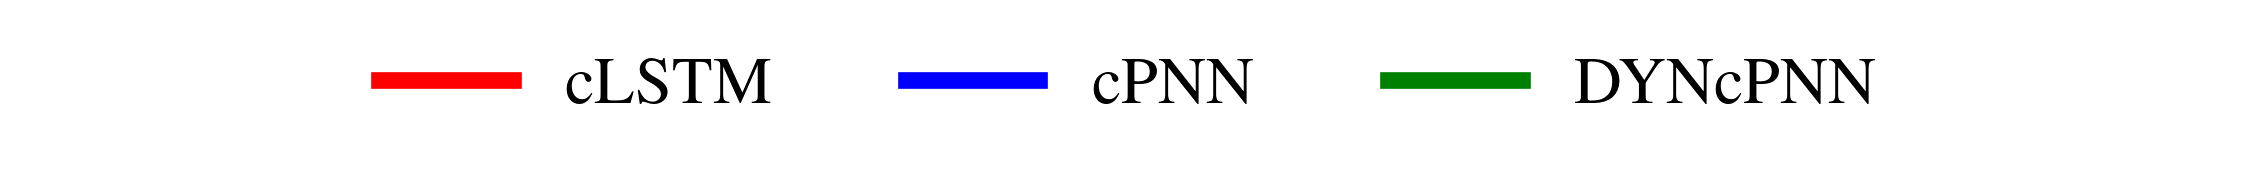

In [8]:
import matplotlib.pyplot as plt
import scienceplots

cm = 1 / 2.54

plt.style.use(['science', 'ieee'])
plt.rcParams.update({'font.size': 8})

# Creazione di una figura vuota per la legenda
fig, ax = plt.subplots(figsize=(12*cm, 0.1*cm))  # Larghezza personalizzabile
ax.axis('off')  # Nascondiamo gli assi

# Dati per la legenda
labels = ['cLSTM', 'cPNN', 'DYNcPNN']
colors = ['red', 'blue', 'green']
linestyles = ['-', '-', '-']

# Generazione delle linee di legenda
lines = [plt.Line2D([0], [0], color=color, linestyle=linestyle, lw=2) for color, linestyle in zip(colors, linestyles)]

# Creazione della legenda
legend = ax.legend(
    lines, labels,
    loc='center',
    ncol=3,  # Per ottenere una legenda orizzontale
    frameon=False,
    fontsize=8
)

# Salvataggio della figura
plt.tight_layout()
plt.savefig(os.path.join(path_write, 'legend_only.eps'), format="eps", bbox_inches='tight')